# ¿Tuvo Marte un océano? La firma que dejó en el suelo

Las líneas de costa propuestas en Marte varían **casi 7 km** de elevación. ¿Eso es una playa o una montaña? Un equipo buscó la pista en otro lado — y la encontró bajo sus pies.

---

📄 **Paper:** *Identifying the topographic signature of early Martian oceans*
**DOI:** [10.1038/s41586-026-10381-2](https://doi.org/10.1038/s41586-026-10381-2) · **Journal:** Nature (2026)

▶️ **Video:** [Pendiente]

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-15-firma-topografica-oceanos-marte/notebook.ipynb)

## La pregunta de los 3.500 millones de años

Llevamos décadas con la misma pregunta: ¿tuvo Marte un océano? La pista clásica son las "líneas de costa" (shorelines) que se ven desde órbita. Pero hay un problema: esas líneas suben y bajan varios kilómetros de elevación. Si fueran playas reales, el agua habría tenido que ignorar la gravedad.

Este equipo hizo algo diferente. En vez de buscar líneas, buscaron la firma que un océano deja en la **topografía** — no una costa abrupta, sino una zona **plana y extensa**: la plataforma costera. En la Tierra, esa zona existe entre −410 m y −15 m de elevación. ¿Hay algo equivalente en Marte?

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
SHELF_MIN = -3800           # Límite inferior plataforma marciana (m)
SHELF_MAX = -1800           # Límite superior plataforma marciana (m)
EARTH_SHELF_MIN = -410      # Plataforma terrestre mín (m)
EARTH_SHELF_MAX = -15       # Plataforma terrestre máx (m)
FUENTE = 'Fuente: Benjamin et al. (2026), Nature | Datos: Zenodo 10.5281/zenodo.18868496'

COLOR_SHELF = '#2563EB'     # Azul CaM — plataforma
COLOR_SHORELINE = '#DC2626' # Rojo — shorelines
COLOR_DELTAS = '#059669'    # Emerald — deltas
COLOR_REFERENCIA = '#D97706'# Amber — referencia
COLOR_CONTEXTO = '#BBBBBB'  # Gris

# ══════════════════════════════════════════════════════════════
import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Descargar datos si no existen localmente
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
DATOS = ['shelf_elevacion_hist.csv', 'shelf_por_latitud.csv', 'shorelines.csv', 'deltas.csv', 'rios_elevacion_hist.csv']
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)
for f in DATOS:
    if not os.path.exists(f'datos/{f}'):
        urllib.request.urlretrieve(f'{BASE}/papers/2026-04-15-firma-topografica-oceanos-marte/datos/{f}', f'datos/{f}')

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Cargar datos
df_hist = pd.read_csv('datos/shelf_elevacion_hist.csv')
df_lat = pd.read_csv('datos/shelf_por_latitud.csv')
df_shores = pd.read_csv('datos/shorelines.csv')
df_deltas = pd.read_csv('datos/deltas.csv')
df_rios = pd.read_csv('datos/rios_elevacion_hist.csv')

print(f"Plataforma costera: {df_hist['count'].sum():,.0f} puntos entre {SHELF_MIN} m y {SHELF_MAX} m".replace(',', '.'))
print(f"Shorelines: {len(df_shores):,.0f} puntos (Arabia: {len(df_shores[df_shores['shoreline']=='Arabia']):,.0f}, Deuteronilus: {len(df_shores[df_shores['shoreline']=='Deuteronilus']):,.0f})".replace(',', '.'))
print(f"Deltas: {len(df_deltas)} depósitos fluviales")

Plataforma costera: 408.690 puntos entre -3800 m y -1800 m
Shorelines: 10.619 puntos (Arabia: 2.039. Deuteronilus: 8.580)
Deltas: 48 depósitos fluviales


## Aquí está la plataforma.

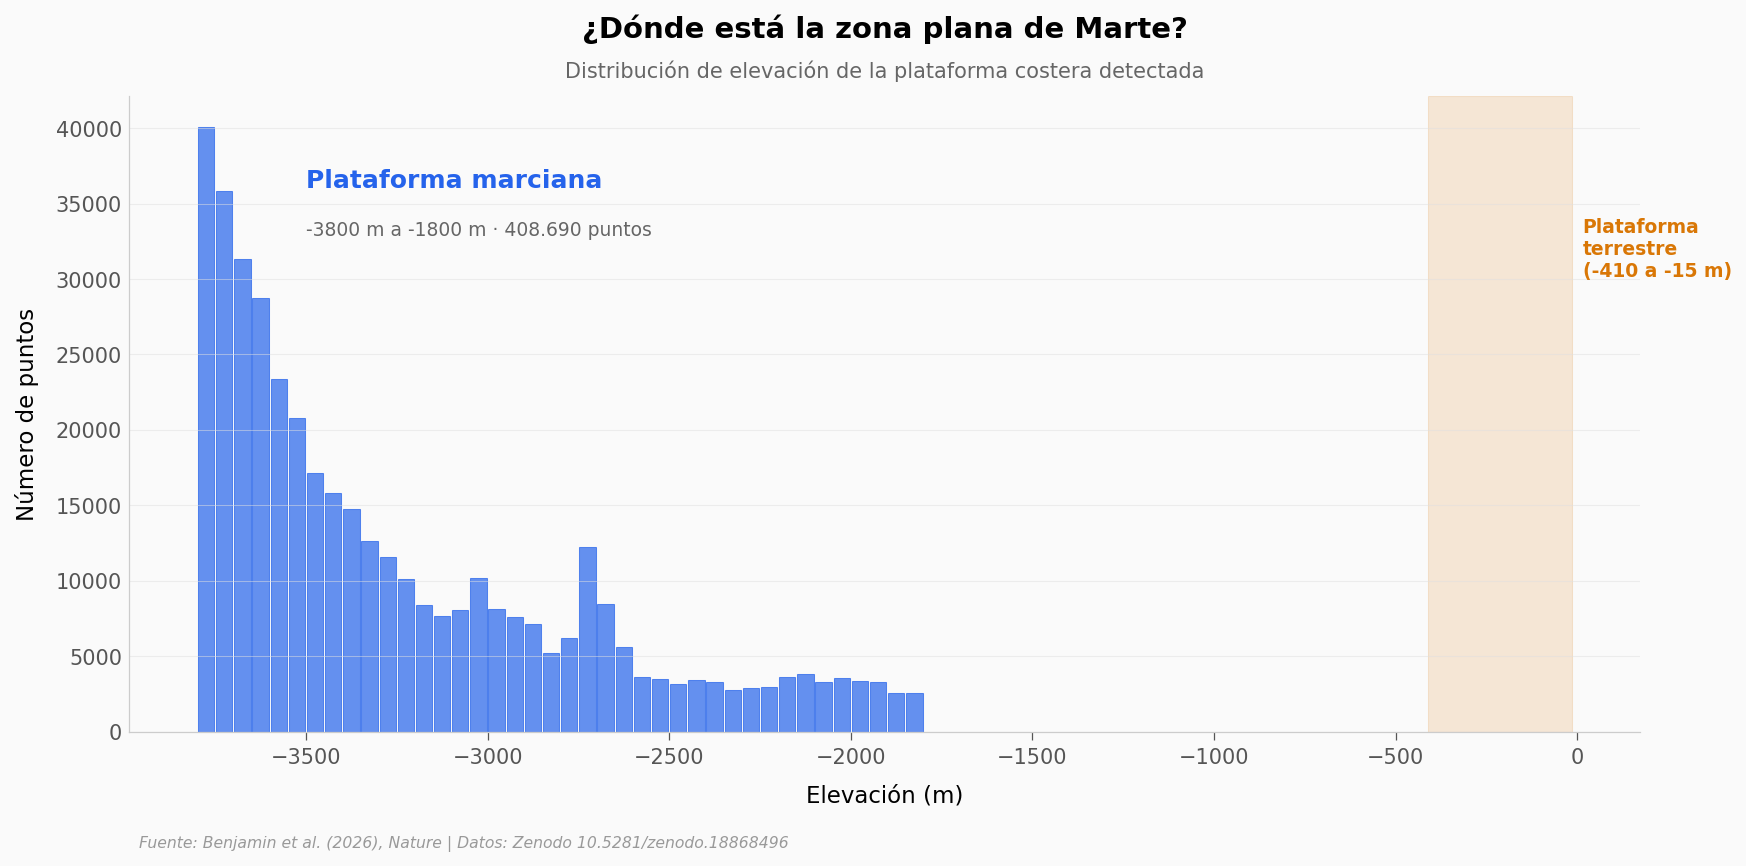

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Histograma de elevación de la plataforma
ax.bar(df_hist['elev_center_m'], df_hist['count'],
       width=45, color=COLOR_SHELF, alpha=0.7, edgecolor=COLOR_SHELF, linewidth=0.5)

# Zona de la plataforma terrestre (escalada para contexto)
ax.axvspan(EARTH_SHELF_MIN, EARTH_SHELF_MAX, alpha=0.15, color=COLOR_REFERENCIA, zorder=0)
ax.text(EARTH_SHELF_MAX + 30, df_hist['count'].max() * 0.85,
        f'Plataforma\nterrestre\n({EARTH_SHELF_MIN} a {EARTH_SHELF_MAX} m)',
        fontsize=9, color=COLOR_REFERENCIA, fontweight='bold', va='top')

# Inline labels
ax.text(-3500, df_hist['count'].max() * 0.9,
        'Plataforma marciana',
        fontsize=12, color=COLOR_SHELF, fontweight='bold')
ax.text(-3500, df_hist['count'].max() * 0.82,
        f'{SHELF_MIN} m a {SHELF_MAX} m · 408.690 puntos',
        fontsize=9, color='#666666')

ax.set_xlabel('Elevación (m)', fontsize=11)
ax.set_ylabel('Número de puntos', fontsize=11)
ax.set_title('¿Dónde está la zona plana de Marte?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución de elevación de la plataforma costera detectada',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_shelf_elevacion.png', dpi=200, bbox_inches='tight')
plt.show()

La concentración de puntos entre −3.800 m y −1.800 m muestra una zona anormalmente plana que rodea todo Marte. No es un cráter ni un flujo de lava localizado — es una banda **circunglobal**.

En la Tierra, la firma equivalente (la plataforma continental + las llanuras costeras) ocupa un rango mucho más estrecho: solo de −410 m a −15 m (la franja ámbar). La marciana es 5 veces más ancha en elevación.

El 97% de estos puntos están en el hemisferio norte, justo donde se concentran las tierras bajas de Marte. Justo donde esperarías encontrar un océano boreal — si existió.

## Las "playas" que no cuadran

Hasta ahora, la evidencia favorita para un océano marciano eran las shorelines — líneas de costa propuestas hace décadas. Pero veamos qué tan irregulares son.

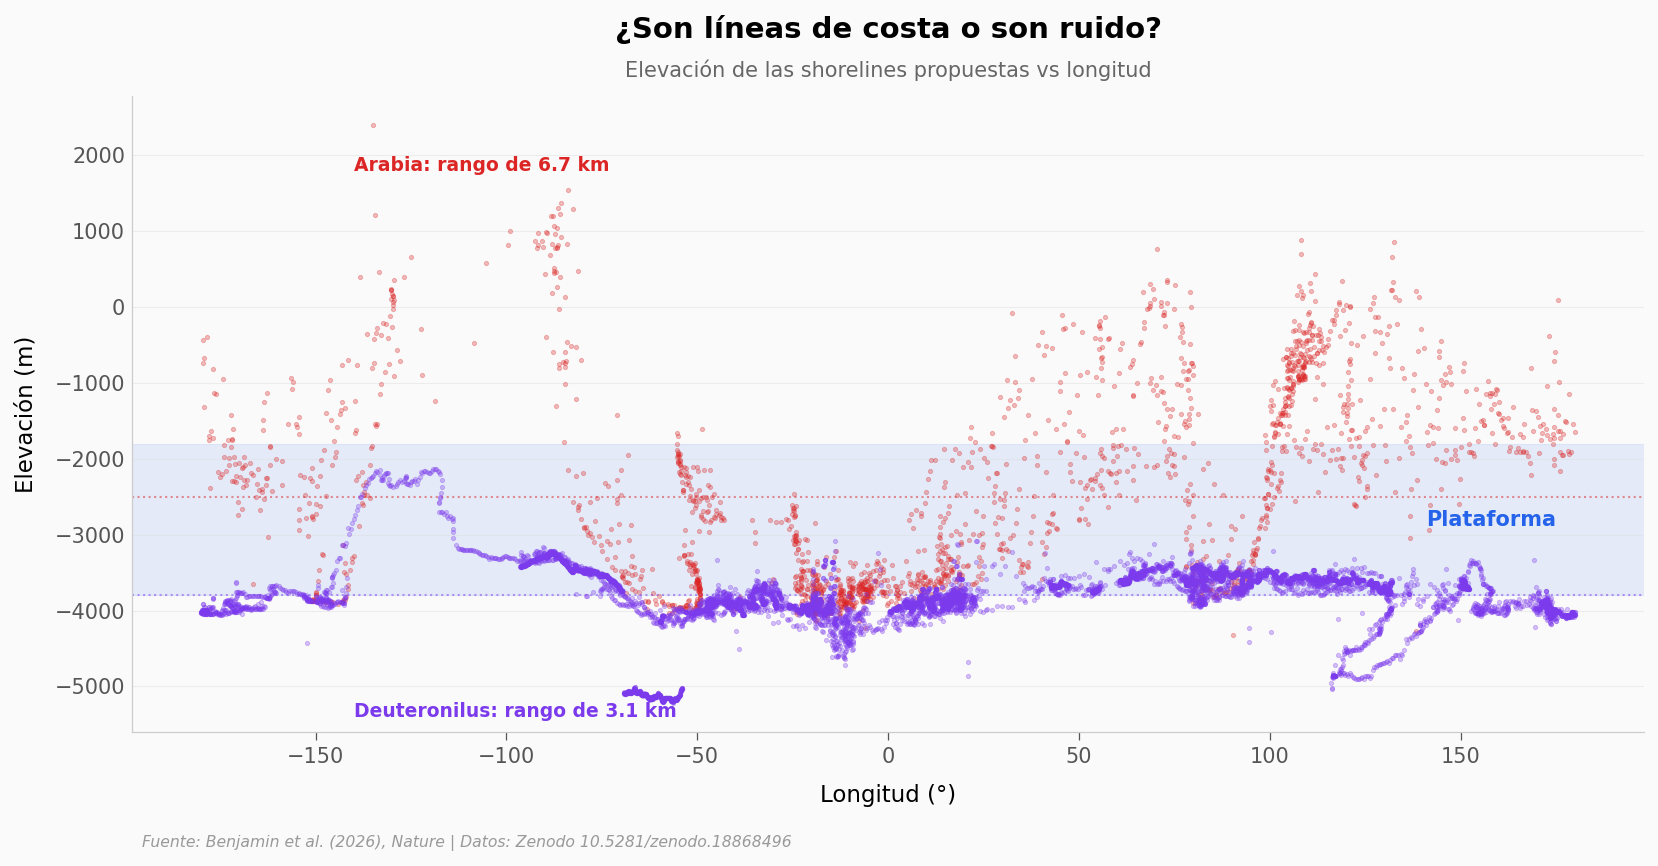

In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Shoreline Arabia
arabia = df_shores[df_shores['shoreline'] == 'Arabia']
ax.scatter(arabia['lon'], arabia['elev_m'], s=4, alpha=0.3,
           color=COLOR_SHORELINE, label='Arabia', zorder=5)

# Shoreline Deuteronilus
deut = df_shores[df_shores['shoreline'] == 'Deuteronilus']
ax.scatter(deut['lon'], deut['elev_m'], s=4, alpha=0.3,
           color='#7C3AED', label='Deuteronilus', zorder=5)

# Zona de la plataforma
ax.axhspan(SHELF_MIN, SHELF_MAX, alpha=0.1, color=COLOR_SHELF, zorder=0)
ax.text(175, (SHELF_MIN + SHELF_MAX) / 2, 'Plataforma',
        fontsize=10, color=COLOR_SHELF, fontweight='bold',
        ha='right', va='center')

# Línea equipotencial hipotética
ax.axhline(y=arabia['elev_m'].median(), color=COLOR_SHORELINE,
           linewidth=1, linestyle=':', alpha=0.5)
ax.axhline(y=deut['elev_m'].median(), color='#7C3AED',
           linewidth=1, linestyle=':', alpha=0.5)

# Inline labels
ax.text(-140, 1800, f'Arabia: rango de {6715/1000:.1f} km',
        fontsize=9, color=COLOR_SHORELINE, fontweight='bold')
ax.text(-140, -5400, f'Deuteronilus: rango de {3081/1000:.1f} km',
        fontsize=9, color='#7C3AED', fontweight='bold')

ax.set_xlabel('Longitud (°)', fontsize=11)
ax.set_ylabel('Elevación (m)', fontsize=11)
ax.set_title('¿Son líneas de costa o son ruido?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Elevación de las shorelines propuestas vs longitud',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/shorelines_variacion.png', dpi=200, bbox_inches='tight')
plt.show()

La shoreline Arabia varía 6,7 km de elevación. Si fuera una playa, el nivel del mar habría tenido que oscilar casi tanto como la altura del Denali — 6,7 km. La Deuteronilus es más "ordenada" (3,1 km), pero aún así es una señal ruidosa.

¿Hay algo que confirme la zona de la plataforma de forma independiente? Sí: los deltas — depósitos donde ríos desembocaban en un cuerpo de agua.

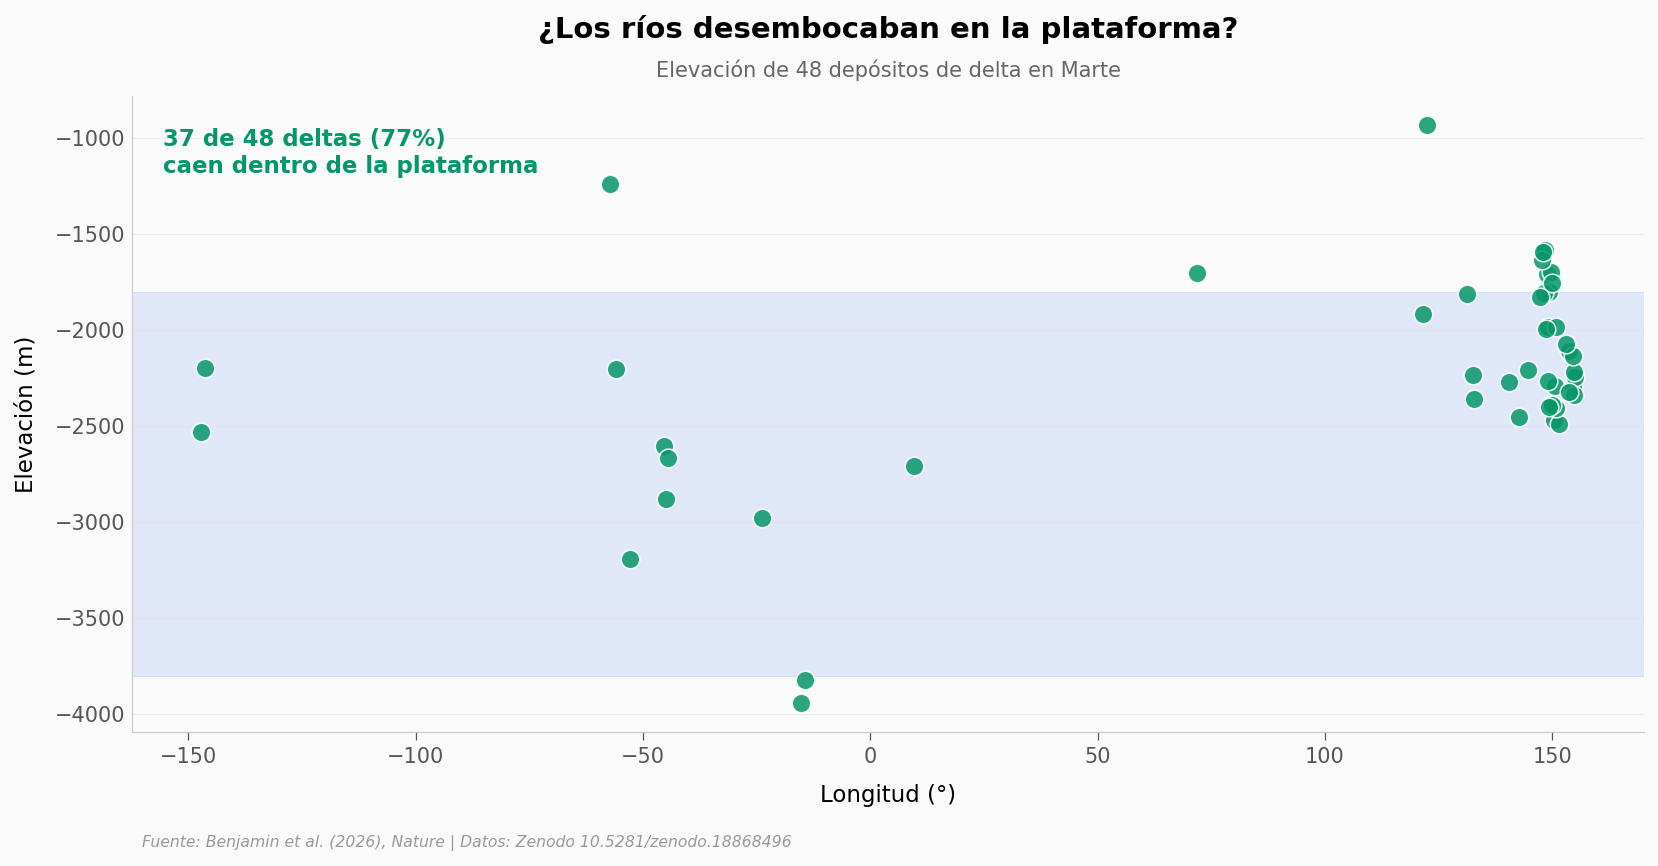

In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Zona de la plataforma
ax.axhspan(SHELF_MIN, SHELF_MAX, alpha=0.12, color=COLOR_SHELF, zorder=0,
           label=f'Plataforma ({SHELF_MIN} a {SHELF_MAX} m)')

# Deltas
ax.scatter(df_deltas['lon'], df_deltas['elev_m'],
           s=80, color=COLOR_DELTAS, edgecolors='white', linewidths=0.8,
           zorder=5, alpha=0.85)

# Contar dentro/fuera
n_dentro = len(df_deltas[(df_deltas['elev_m'] >= SHELF_MIN) & (df_deltas['elev_m'] <= SHELF_MAX)])
n_total = len(df_deltas)

# Inline labels
ax.text(0.02, 0.95, f'{n_dentro} de {n_total} deltas ({n_dentro/n_total*100:.0f}%)\ncaen dentro de la plataforma',
        transform=ax.transAxes, fontsize=11, color=COLOR_DELTAS,
        fontweight='bold', va='top')

ax.set_xlabel('Longitud (°)', fontsize=11)
ax.set_ylabel('Elevación (m)', fontsize=11)
ax.set_title('¿Los ríos desembocaban en la plataforma?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Elevación de 48 depósitos de delta en Marte',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/deltas_en_plataforma.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan diferente es esta plataforma del resto de Marte?

37 de 48 deltas caen dentro de la zona de la plataforma. Los ríos no desembocaban en cualquier parte: convergían hacia la misma franja de elevación que ya vimos como anormalmente plana.

Pero queda una pregunta: ¿es la plataforma realmente **especial**, o todo Marte tiene zonas planas?

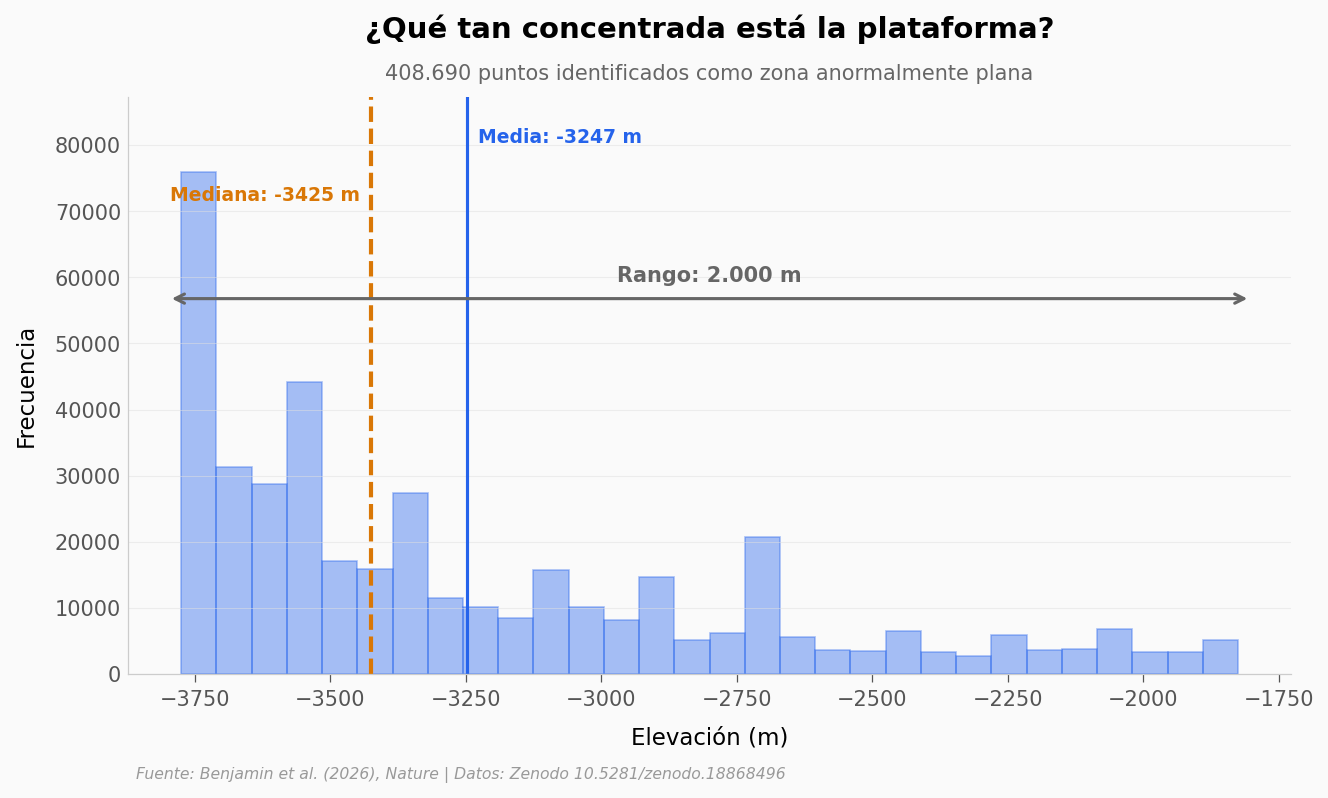

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

# Distribución de elevaciones del shelf
elevs = df_hist['elev_center_m'].values
counts = df_hist['count'].values
media_pond = np.average(elevs, weights=counts)
mediana = elevs[np.searchsorted(np.cumsum(counts), counts.sum() / 2)]

n, bins, patches = ax.hist(elevs, bins=30, weights=counts,
                           color=COLOR_SHELF, alpha=0.4,
                           edgecolor=COLOR_SHELF, linewidth=0.8)

y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

# Línea de la media
ax.axvline(x=media_pond, color=COLOR_SHELF, linewidth=1.5, linestyle='-')
ax.text(media_pond + 20, y_max * 0.92, f'Media: {media_pond:.0f} m',
        fontsize=9, color=COLOR_SHELF, fontweight='bold')

# Línea de la mediana
ax.axvline(x=mediana, color=COLOR_REFERENCIA, linewidth=2, linestyle='--')
ax.text(mediana - 20, y_max * 0.82, f'Mediana: {mediana:.0f} m',
        fontsize=9, color=COLOR_REFERENCIA, fontweight='bold', ha='right')

# Flecha de rango total
ax.annotate('', xy=(SHELF_MAX, y_max * 0.65), xytext=(SHELF_MIN, y_max * 0.65),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((SHELF_MIN + SHELF_MAX) / 2, y_max * 0.68,
        f'Rango: {abs(SHELF_MAX - SHELF_MIN):,.0f} m'.replace(',', '.'),
        fontsize=10, color='#666666', ha='center', fontweight='bold')

ax.set_xlabel('Elevación (m)', fontsize=11)
ax.set_ylabel('Frecuencia', fontsize=11)
ax.set_title('¿Qué tan concentrada está la plataforma?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '408.690 puntos identificados como zona anormalmente plana',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_anomalia.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Existe una zona plana entre −3.800 m y −1.800 m en Marte | ✅ | 408.690 puntos en Zenodo. Coincide exactamente con el rango del paper |
| Las shorelines propuestas varían kilómetros | ✅ | Arabia: 6,7 km de rango. Deuteronilus: 3,1 km. Verificado en datos |
| La plataforma se concentra en el hemisferio norte | ✅ | 97,4% de los puntos están al norte del ecuador |
| Los deltas convergen hacia la plataforma | ✅ | 37/48 (77%) caen dentro del rango −3.800 a −1.800 m |
| La plataforma es evidencia de un océano | ⚠️ | El paper usa "potentially" y "support" — no es prueba definitiva. Flujos de lava podrían explicar zonas planas localmente |
| El océano cubría 1/3 de la superficie | ⚠️ | Dato del paper, no verificable con los datos de elevación disponibles |

> **Limitaciones:** (1) Los datos topográficos no son una prueba directa de agua — la forma plana podría tener otros orígenes (vulcanismo). El paper lo reconoce. (2) Las coordenadas de la plataforma vienen del análisis de slope/curvature del paper, no de una medición directa de agua. (3) Solo analizamos la distribución de elevación — el análisis de slope y curvature del paper no está en los datos de Zenodo descargados (están en el ZIP de 2,8 GB).

## Ahora tú

1. **¿Qué pasa si movemos la plataforma?** Cambia `SHELF_MIN` y `SHELF_MAX` en la celda de configuración. ¿Cuántos deltas quedan dentro si subes el límite superior a −1.500 m?

2. **¿Dónde se concentran los deltas?** ¿Hay alguna longitud con más deltas que otras? Prueba: `df_deltas['lon'].hist(bins=36)` para ver la distribución longitudinal.

3. **¿La shoreline Deuteronilus se parece más a la plataforma que la Arabia?** Compara sus distribuciones de elevación con la de la plataforma.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Qué fracción de deltas cae en la zona de la plataforma
# si cambias los límites?

limite_sup_nuevo = -1500  # Prueba cambiando este valor

n_dentro_nuevo = len(df_deltas[
    (df_deltas['elev_m'] >= SHELF_MIN) &
    (df_deltas['elev_m'] <= limite_sup_nuevo)
])
print(f"Con plataforma hasta {limite_sup_nuevo} m:")
print(f"  {n_dentro_nuevo}/{len(df_deltas)} deltas ({n_dentro_nuevo/len(df_deltas)*100:.0f}%)")
print(f"  vs {37}/{len(df_deltas)} (77%) con el límite original de {SHELF_MAX} m")

Con plataforma hasta -1500 m:
  44/48 deltas (92%)
  vs 37/48 (77%) con el límite original de -1800 m


---

## Créditos

- **Paper:** Benjamin, D. et al. (2026). *Identifying the topographic signature of early Martian oceans.* Nature. DOI: [10.1038/s41586-026-10381-2](https://doi.org/10.1038/s41586-026-10381-2)
- **Datos:** [Zenodo — 10.5281/zenodo.18868496](https://doi.org/10.5281/zenodo.18868496) (Topographic data and derived products)
- **Licencia datos:** Creative Commons Attribution 4.0
- **Notebook:** [El Lab — Ciencia a Mordiscos](https://cienciaamordiscos.com)